### Medical abstracts — T5 fine-tuning

Use this notebook for **EDA, baselines, and T5 fine-tuning** on the medical abstract classification task. (Zero-shot prompt experiments for this domain live in `archieve/` alongside older drafts.)

In [ ]:
import re
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
#from sklearn.metrics import accuracy_score, f1_score, precision_score,precision_recall_fscore_support, recall_score
from sklearn.metrics import classification_report,precision_recall_fscore_support, accuracy_score,precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from datasets import load_dataset,Dataset,concatenate_datasets
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    Trainer,
    TrainingArguments,
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    AutoModelForSequenceClassification,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

#from datasets import Dataset
import torch

from torch.utils.data import DataLoader, WeightedRandomSampler, TensorDataset

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"


In [ ]:
dryRun = False  # True = tiny subset for quick experiments; keep False for full training.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

colab_dir = "/content/gdrive/MyDrive/Colab Notebooks/"
base_dir = colab_dir + "d266/FinalProject/"

Mounted at /content/gdrive/


## Load dataset

In [ ]:
# Define the label mapping
label_map = {
    1: "Neoplasms",
    2: "Digestive system diseases",
    3: "Nervous system diseases",
    4: "Cardiovascular diseases",
    5: "General pathological conditions",
}

In [ ]:
# Load the dataset and map to text diagnoses
ds = load_dataset("TimSchopf/medical_abstracts")

train, ds_test = ds["train"], ds["test"]

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/7.67M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11550 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2888 [00:00<?, ? examples/s]

In [ ]:

#example = train["condition_label"]-1
train_df = train.to_pandas().dropna()
test_df  = ds_test.to_pandas().dropna()

print(f"Original train length: {len(train_df)}")
print(f"Original test length: {len(test_df)}")

Original train length: 11550
Original test length: 2888


In [ ]:
# Reindex to 0 immediately

train_df["condition_label"] = train_df["condition_label"]
test_df["condition_label"] = test_df["condition_label"]

In [ ]:
# Check for multi-label classification for medical abstracts
(
    train_df.groupby("medical_abstract")["condition_label"]
    .nunique()
    .value_counts()
)


,count
condition_label,
1,7489
2,1810
3,143
4,3


In [ ]:
# Check for multi-label classification for medical abstracts
(
    test_df.groupby("medical_abstract")["condition_label"]
    .nunique()
    .value_counts()
)

,count
condition_label,
1,2657
2,108
3,5


In [ ]:
def random_label(df):
    def pick_random_label(labels):
        labels = list(labels)
        return np.random.choice(labels)

    winners = (
        df.groupby("medical_abstract")["condition_label"]
          .apply(pick_random_label)
          .reset_index(name="random_label")
    )
    winners = winners.sample(frac=1.0, random_state=42).reset_index(drop=True)

    return winners

train_random = random_label(train_df)
test_random  = random_label(test_df)

## Data Visualizations

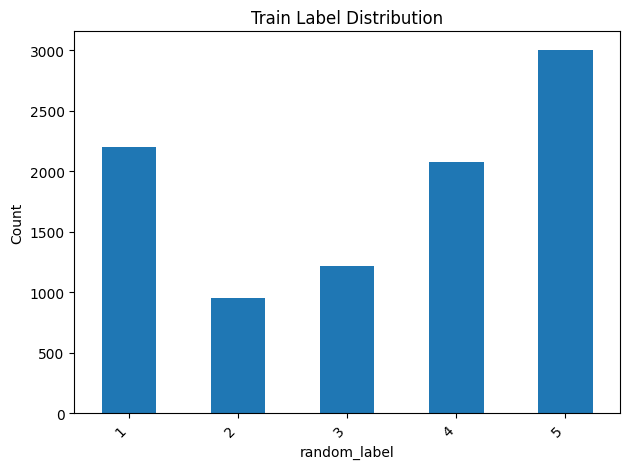

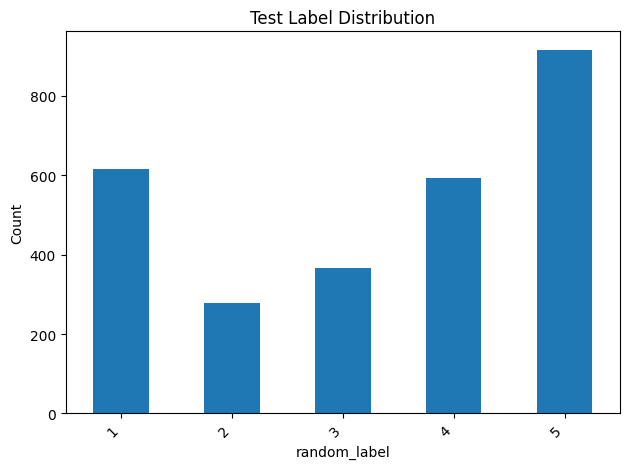

In [ ]:
# Visualizing label distributions
train_counts = train_random["random_label"].value_counts().sort_index()
train_counts.plot(kind="bar", title="Train Label Distribution")
plt.xlabel("random_label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

test_counts = test_random["random_label"].value_counts().sort_index()
test_counts.plot(kind="bar", title="Test Label Distribution")
plt.xlabel("random_label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Training test splits

In [ ]:
train_df_split, val_df_split = train_test_split(
    train_random,
    test_size=0.3,
    random_state=42,
    stratify=train_random["random_label"]
)

train_df_split = train_df_split.reset_index(drop=True)
val_df_split = val_df_split.reset_index(drop=True)

In [ ]:
# Rename the columns to match tensor format 
train_df = train_df_split[["medical_abstract", "random_label"]].rename(columns={
    "medical_abstract": "text",
    "random_label": "label"
})

val_df = val_df_split[["medical_abstract", "random_label"]].rename(columns={
    "medical_abstract": "text",
    "random_label": "label"
})

test_df = test_random[["medical_abstract", "random_label"]].rename(columns={
    "medical_abstract": "text",
    "random_label": "label"
})

In [ ]:
label2id = {
    "Neoplasms": 0,
    "Digestive system diseases": 1,
    "Nervous system diseases": 2,
    "Cardiovascular diseases": 3,
    "General pathological conditions": 4,
}

id2label = {v: k for k, v in label2id.items()}

train_ds = Dataset.from_pandas(train_df[["text","label"]], preserve_index=False)
val_ds   = Dataset.from_pandas(val_df[["text","label"]],   preserve_index=False)
test_ds  = Dataset.from_pandas(test_df[["text","label"]],  preserve_index=False)

## Check the format

In [ ]:
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 6611
})

In [ ]:
val_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 2834
})

In [ ]:
print("Train split shape :",train_ds.shape)
#print("Train Label length : ",len(y_train))
print("Val split shape :",val_ds.shape)

Train split shape : (6611, 2)
Val split shape : (2834, 2)


# Fine Tuning Section

## Token config

In [ ]:
model_name = "t5-base" # Model name
if os.path.exists(base_dir+"t5_basetoken"):
  print("Loaded base model from local folder:",base_dir+"t5_basetoken")
  tokenizer = AutoTokenizer.from_pretrained(base_dir+"t5_basetoken")
else:
  print("Loading base model from Hugging Face")
  tokenizer = AutoTokenizer.from_pretrained(model_name)
  tokenizer.save_pretrained(base_dir+"t5_basetoken")

Loaded base model from local folder: /content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/t5_basetoken


In [ ]:
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 6611
})

In [ ]:
# chanegs for imoproving max_length=2 - > 512
def preprocess_function(examples):
    inputs = ["Classify the medical abstract give rating 1 to 5: " + text for text in examples["text"]]
    # max_length =256
    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding="max_length")

    # Convert labels to string tokens
    # padding="max_length"
    with tokenizer.as_target_tokenizer():
        labels = tokenizer([str(label) for label in examples["label"]],
                           max_length=2, truncation=True, padding=False)

    model_inputs["label"] = labels["input_ids"]
    return model_inputs


tokenized_train = train_ds.map(preprocess_function, batched=True)
tokenized_val = val_ds.map(preprocess_function, batched=True)

#===============================================================
# Use this line when you want to experiment with smaller data set
#===============================================================
if dryRun:
  print("Applying dryRunConfig")
  tokenized_train = tokenized_train.select(range(1000))
  tokenized_val = tokenized_val.select(range(20))
  num_train_epochs = 1
  train_batch_size = 4
  val_batch_size = 4
else:
  num_train_epochs = 5
  train_batch_size = 8
  val_batch_size = 16

Map:   0%|          | 0/6611 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4118: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/2834 [00:00<?, ? examples/s]

# Load tensorboard dashboard to analyse training

In [ ]:
#!rm -rf ./runs #If you see errors like “TensorBoard already running,” clear it with:

#%load_ext tensorboard
#%tensorboard --logdir ./logs

In [ ]:
custom_cache_path = base_dir+"t5_basemodel_cache/model--t5-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = AutoModelForSeq2SeqLM.from_pretrained(model_name,ignore_mismatched_sizes=True,cache_dir=custom_cache_path).to(device)

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

# Define metrics

In [ ]:

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Strip spaces, map to ints if possible
    decoded_preds = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    # Filter invalid preds
    valid = [p for p in decoded_preds if p.isdigit()]
    return {
        "accuracy": accuracy_score(decoded_labels, decoded_preds),
        "precision": precision_score(decoded_labels, decoded_preds, average="macro", zero_division=0),
        "recall": recall_score(decoded_labels, decoded_preds, average="macro", zero_division=0),
        "f1": f1_score(decoded_labels, decoded_preds, average="macro", zero_division=0),
        "macro_f1": f1_score(decoded_labels, decoded_preds, average="macro"),
        "weighted_f1": f1_score(decoded_labels, decoded_preds, average="weighted"),
    }



In [ ]:
def preprocess_logits_for_metrics(logits, labels):
    # logits: (batch, num_labels)
    return logits.argmax(dim=-1)

# Training Starts

In [ ]:
model.config.return_dict = True

training_args = Seq2SeqTrainingArguments(
    output_dir=base_dir+"t5_classification",
    seed=42,
    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=val_batch_size,
    num_train_epochs=num_train_epochs,
    learning_rate=5e-5,#3e-4,5e-5,1e-4
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to=None,
    load_best_model_at_end=True,
    metric_for_best_model="weighted_f1",
    greater_is_better=True,

    #early_stopping_patience=3,

    # This was added earlier. Accuracy = 0.60
    gradient_accumulation_steps=2,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    logging_dir="./logs",
    logging_steps=10,
    predict_with_generate=True,
    push_to_hub=False,

)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    #preprocess_logits_for_metrics=preprocess_logits_for_metrics,
)
print("Training Argument : epoch ",num_train_epochs)

from datetime import datetime

# Get the current date and time
start_time = datetime.now()
print(start_time)
print("Start Time : ",start_time.strftime("%H:%M:%S"))
#****************
trainer.train()
#****************

end_time = datetime.now()
print("Time Ended :", end_time)

#trainer.train()

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-1323398398.py:40: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Training Argument : epoch  5
2025-12-01 01:47:09.018220
Start Time :  01:47:09


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1,Weighted F1
1,0.495300,0.511189,0.644319,0.621957,0.670637,0.623581,0.623581,0.614359
2,0.354300,0.420360,0.694072,0.678021,0.703538,0.683438,0.683438,0.681087
3,0.416800,0.393180,0.703952,0.689035,0.704757,0.694015,0.694015,0.696326
4,0.384400,0.402891,0.706422,0.688402,0.715389,0.697923,0.697923,0.698641
5,0.375700,0.403016,0.707481,0.689976,0.714337,0.698778,0.698778,0.700495


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Time Ended : 2025-12-01 02:18:45.838366


In [ ]:
#current_datetime.strftime("%H:%M:%S")-current_datetime2.strftime("%H:%M:%S")
# Calculate the difference, which results in a timedelta object
duration = end_time - start_time

# Print the timedelta object
print(f"Duration: {duration}")

# Access components of the duration
print(f"Days: {duration.days}")
print(f"Total seconds: {duration.total_seconds()}")

# Format the duration for a more readable output
minutes, seconds = divmod(duration.total_seconds(), 60)
hours, minutes = divmod(minutes, 60)
print(f"Duration: {int(hours)} hours, {int(minutes)} minutes, {int(seconds)} seconds")

Duration: 0:31:36.820146
Days: 0
Total seconds: 1896.820146
Duration: 0 hours, 31 minutes, 36 seconds


# Save the model and tokens

In [ ]:
base_dir = colab_dir + "d266/FinalProject/"

base_dir+"t5base_finetuned_medicalabstract"

'/content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/t5base_finetuned_medicalabstract'

## Save model and tokenizer

In [ ]:
base_dir = colab_dir + "d266/FinalProject/"

trainer.save_model(base_dir+"t5base_finetuned_medicalabstract")
tokenizer.save_pretrained(base_dir+"t5base_finetuned_medicalabstract")

print(f"Model, tokenizer saved to {base_dir}t5base_finetuned_medicalabstract")

Model, tokenizer saved to /content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/t5base_finetuned_medicalabstract


# Evaluate

In [ ]:
# comment train
metrics = trainer.evaluate()
print("\n=== Evaluation Summary ===")
print(metrics)


=== Evaluation Summary ===
{'eval_loss': 0.40301600098609924, 'eval_accuracy': 0.7074805928016937, 'eval_precision': 0.6899764860455683, 'eval_recall': 0.7143370207172836, 'eval_f1': 0.6987780412162955, 'eval_macro_f1': 0.6987780412162955, 'eval_weighted_f1': 0.7004951924651067, 'eval_runtime': 63.2078, 'eval_samples_per_second': 44.836, 'eval_steps_per_second': 2.816, 'epoch': 5.0}


### Confusion Matrix for Val data

['2', '1', '1', '3', '4', '5', '5', '1', '4', '5', '5', '5', '5', '3', '5', '4', '4', '5', '2', '2', '4', '2', '3', '1', '1', '1', '1', '3', '5', '4', '5', '5', '4', '3', '2', '5', '1', '5', '3', '5', '4', '1', '4', '1', '3', '3', '5', '1', '4', '4', '5', '5', '1', '4', '3', '3', '1', '5', '3', '5', '4', '4', '2', '1', '2', '3', '1', '1', '1', '3', '4', '4', '5', '5', '2', '3', '3', '3', '1', '5', '2', '4', '5', '5', '1', '2', '1', '3', '1', '5', '5', '5', '2', '3', '1', '4', '1', '3', '5', '4', '2', '5', '1', '1', '5', '4', '4', '1', '5', '3', '5', '1', '1', '4', '5', '1', '5', '4', '2', '4', '3', '4', '4', '3', '5', '4', '1', '1', '1', '4', '2', '4', '3', '2', '4', '2', '1', '5', '2', '4', '4', '5', '1', '3', '2', '4', '4', '2', '5', '4', '4', '3', '1', '5', '5', '4', '2', '2', '5', '1', '1', '4', '5', '2', '1', '1', '2', '5', '5', '1', '5', '1', '2', '1', '3', '3', '2', '1', '4', '5', '2', '2', '5', '5', '4', '3', '4', '3', '1', '4', '5', '4', '2', '1', '4', '5', '3', '1', '4', '5',

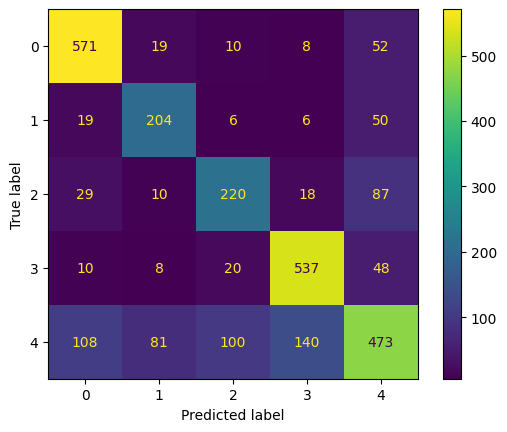

In [ ]:
preds_output_val = trainer.predict(tokenized_val)

# Get preds and labels
y_pred = preds_output_val.predictions
y_true = preds_output_val.label_ids

# decode labels
decoded_labels_val = tokenizer.batch_decode(
    preds_output_val.label_ids, skip_special_tokens=True
)
print(decoded_labels_val,len(decoded_labels_val))
decoded_preds = tokenizer.batch_decode(
    preds_output_val.predictions, skip_special_tokens=True
)
"""
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=decoded_labels_val)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()
"""
cm = confusion_matrix(decoded_labels_val, decoded_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()



# Inference/Prediction

# Tokenize the test data

In [ ]:
#tokenized_test  = df_test.map(preprocess_fn, batched=True, remove_columns=["text"])
#preprocess_function
#df_test  = Dataset.from_pandas(test_ds[["text", "rating_bucket"]].rename(columns={"rating_bucket": "labels"}))
#df_test = test_ds.rename(columns={"rating_bucket": "text","":"labels"}))
df_test = test_ds.select(range(15))
df_test

Dataset({
    features: ['text', 'label'],
    num_rows: 15
})

In [ ]:
tokenized_test = df_test.map(preprocess_function, batched=True)

tokenized_test.set_format(type="torch", columns=["text","input_ids", "attention_mask", "label"])
tokenized_test = tokenized_test.select(range(15))
print("Tokenised test shape : ",tokenized_test.shape)

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4118: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Tokenised test shape :  (15, 4)


In [ ]:
tokenized_test

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 15
})

In [ ]:
tokenized_test['label']

Column([tensor([305,   1]), tensor([314,   1]), tensor([220,   1]), tensor([305,   1]), tensor([209,   1])])

In [ ]:

print("Test eval:")
#preds_output = trainer.predict(tokenized_test)
preds_output = trainer.predict(tokenized_test)

print(preds_output.metrics)


Test eval:


{'test_loss': 0.33419403433799744, 'test_accuracy': 0.7333333333333333, 'test_precision': 0.7619047619047619, 'test_recall': 0.8333333333333334, 'test_f1': 0.7333333333333334, 'test_macro_f1': 0.7333333333333334, 'test_weighted_f1': 0.6911111111111111, 'test_runtime': 0.631, 'test_samples_per_second': 23.77, 'test_steps_per_second': 1.585}


In [ ]:
# -------------------------
# Evaluate on test set
# -------------------------
print("Validation eval:")
print(trainer.evaluate(tokenized_val))

Validation eval:


{'eval_loss': 0.40301600098609924, 'eval_accuracy': 0.7074805928016937, 'eval_precision': 0.6899764860455683, 'eval_recall': 0.7143370207172836, 'eval_f1': 0.6987780412162955, 'eval_macro_f1': 0.6987780412162955, 'eval_weighted_f1': 0.7004951924651067, 'eval_runtime': 58.6661, 'eval_samples_per_second': 48.307, 'eval_steps_per_second': 3.034, 'epoch': 5.0}


## End Of File